In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random


In [2]:
def get_column(data, index):
    return [row[index] for row in data]

def prepare_data(file_name_data):
    data = np.genfromtxt(file_name_data, delimiter=',', skip_header=1).tolist() #skip_header=1 để bỏ qua dòng đầu tiên
    N=len(data)
    tv_data = get_column(data, 0)
    radio_data = get_column(data,1)
    newspaper_data = get_column(data,2)
    sales_data = get_column(data,3)
    X = [tv_data,radio_data,newspaper_data]
    y = sales_data
    return X,y

X,y = prepare_data('advertising.csv')
list = [sum(X[0][:5]),sum(X[1][:5]),sum(X[2][:5]),sum(y[:5])]
print(list)




[624.1, 175.10000000000002, 300.5, 78.9]


In [3]:
def initialize_params():
    w1 = np.random.randn()
    w2 = np.random.randn()
    w3 = np.random.randn()
    b = 0
    return w1, w2, w3, b
print(initialize_params())

(0.42788025472749347, -0.8221895355962346, 0.6771897371656372, 0)


In [4]:
def predict(x1,x2,x3,w1,w2,w3,b):
    return w1*x1+w2*x2+w3*x3+b

y_test = predict(1,1,1,0,0.5,0,0.5)
print(y_test)

1.0


In [5]:
def compute_loss(y_hat,y):
    return (y_hat-y)**2
l = compute_loss(1,0.5)
print(l)

0.25


In [6]:
def compute_grad_wi (xi,y,y_hat):
    return -2*xi*(y-y_hat)

def compute_grad_b(y,y_hat):
    return -2*(y-y_hat)

print(compute_grad_wi(1,1,0.5))

-1.0


In [76]:
def update_weights(wi,dl_wi,lr):
    return wi - lr * dl_wi
def update_bias(bi ,dl_bi,lr):
    return bi - lr * dl_bi

print(update_weights(1,0.5,1e-5))
print(update_bias(0.5,1,1e-5))

0.999995
0.49999


In [77]:
def implement_linear_regression(X_data,y_data, epoch_max = 50, lr = 1e-5):
    losses =[]
    w1,w2,w3,b = initialize_params()
    N=len(y_data)
    for epoch in range(epoch_max):
        for i in range(N):
            X1 = X_data[0][i]
            X2 = X_data[1][i]
            X3 = X_data[2][i]
            y = y_data[i]

            y_hat = predict(X1,X2,X3,w1,w2,w3,b)
        
            loss = compute_loss(y_hat,y)
            dl_w1 = compute_grad_wi(X1,y,y_hat)
            dl_w2 = compute_grad_wi(X2,y,y_hat)
            dl_w3 = compute_grad_wi(X3,y,y_hat)
            dl_b = compute_grad_b(y,y_hat)

            w1 = update_weights(w1,dl_w1,lr)
            w2 = update_weights(w2,dl_w2,lr)
            w3 = update_weights(w3,dl_w3,lr)
            b = update_bias(b,dl_b,lr)
        
            losses.append(loss)
    return (w1,w2,w3,b,losses)
    

[63251.60751431166, 953.3151595711115, 1535.6839550031161, 662.5790879713803, 42.564466041068115, 690.9613329409269, 57.50770343615081, 34.018850004167824, 13.109572713210735, 192.06331531868025, 102.69583990780662, 67.05381929826203, 444.7526457277265, 26.943454315908014, 20.818420868286367, 40.52910956788307, 402.3744592343021, 436.170625588707, 90.69777970180562, 34.03098245987206, 17.791809379484967, 42.28527610085174, 116.59731205020628, 16.423241619261656, 27.972713327655978, 97.3005593225775, 64.83242764175793, 14.49161913621126, 12.853084067443712, 84.88292217848841, 4.4802277154591, 43.21178487573637, 45.752017517660576, 146.88983752317532, 67.19982586050615, 0.3801485064077141, 67.3095677150475, 106.22398204120725, 51.16883222842619, 45.069074540566525, 2.1380687818388835, 9.432592053782574, 113.14016002852439, 124.38530392464274, 84.43325911610803, 2.0565675213018135, 16.084510858650344, 3.736042113056804, 0.8005541020774756, 26.529209737128813, 8.754324161493233, 1.23257795

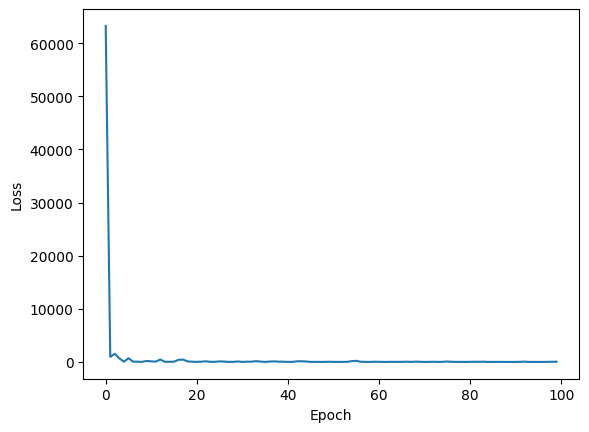

In [78]:
(w1,w2,w3,b,losses)= implement_linear_regression(X,y)
print(losses[0:100]) 
plt.plot(losses[0:100])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()